# Module 6: GPU-Accelerated XGBoost Training

**High-Performance Model Training on GPU**

In this notebook, you'll:
- Load the feature-engineered data from Module 3
- Train XGBoost models using GPU acceleration
- Perform cross-validation and hyperparameter tuning
- Evaluate model performance and feature importance
- Generate predictions for submission

**Libraries Used:**
- `XGBoost` with GPU support for fast training
- `scikit-learn` for model evaluation
- `matplotlib` and `seaborn` for visualization
- `SHAP` for model explanations

## Environment Setup

In [1]:
%load_ext cudf.pandas

/home/allisond/miniconda/envs/rapids-25.12-python-3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import time
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd

# XGBoost and sklearn
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Data paths
DATA_DIR = Path("./data")
FEATURE_DIR = DATA_DIR / "features"
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print(f"\nData directory: {DATA_DIR}")
print(f"Model directory: {MODEL_DIR}")

XGBoost version: 3.1.2

Data directory: data
Model directory: data/models


## Load Feature-Engineered Data

In [3]:
# Load engineered features
print("Loading feature-engineered data...")
start = time.perf_counter()

train_df = pd.read_parquet(FEATURE_DIR / "train_features.parquet")
test_df = pd.read_parquet(FEATURE_DIR / "test_features.parquet")

# Load feature list
with open(FEATURE_DIR / "feature_cols.txt", 'r') as f:
    feature_cols = f.read().strip().split('\n')

# Filter to only numeric features that exist
available_features = [col for col in feature_cols if col in train_df.columns]
feature_cols = available_features

print(f"Load time: {time.perf_counter() - start:.2f}s")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Available features: {len(feature_cols)}")
print(f"Fraud rate: {train_df['isFraud'].mean():.2%}")

Loading feature-engineered data...
Load time: 0.84s
Train shape: (590540, 464)
Test shape: (506691, 463)
Available features: 461
Fraud rate: 3.50%


## Exploratory Data Analysis

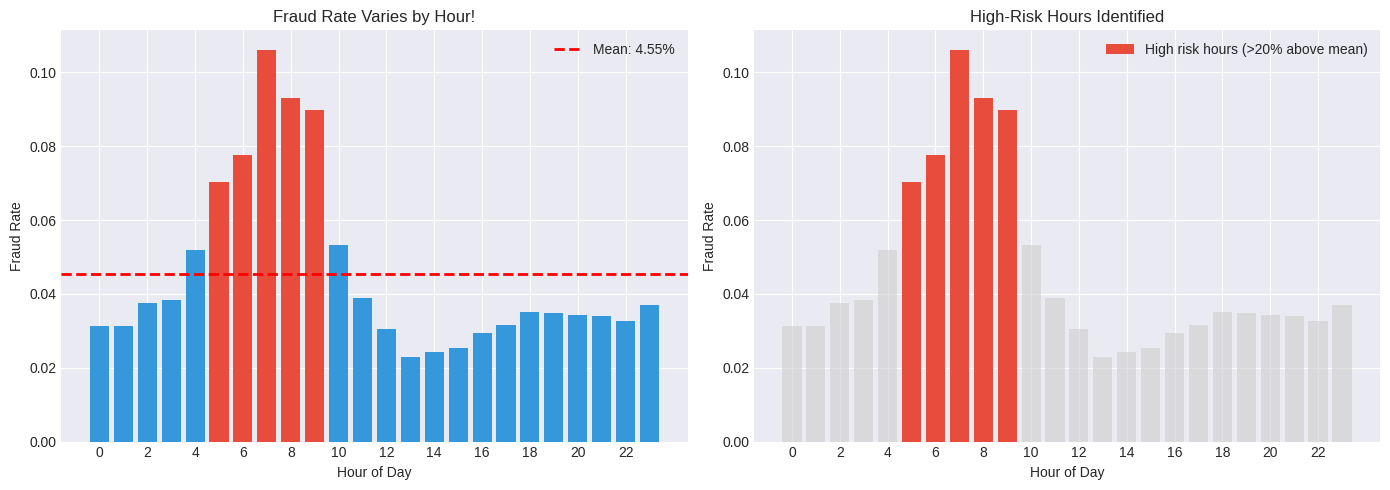


High-risk hours (>20% above mean): [5, 6, 7, 8, 9]
Hour range for fraud: 2.29% - 10.61%


In [4]:
# Fraud rate by hour
fraud_by_hour = train_df.groupby('transaction_hour')['isFraud'].mean()

# Visualize time patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
colors = ['#e74c3c' if x > fraud_by_hour.mean() * 1.2 else '#3498db' for x in fraud_by_hour.values]
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color=colors)
axes[0].axhline(y=fraud_by_hour.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {fraud_by_hour.mean():.2%}')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate')
axes[0].set_title('Fraud Rate Varies by Hour!')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# Highlight high-risk hours
high_risk = fraud_by_hour[fraud_by_hour > fraud_by_hour.mean() * 1.2]
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='lightgray', alpha=0.7)
axes[1].bar(high_risk.index, high_risk.values, color='#e74c3c', label='High risk hours (>20% above mean)')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('High-Risk Hours Identified')
axes[1].legend()
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print(f"\nHigh-risk hours (>20% above mean): {list(high_risk.index)}")
print(f"Hour range for fraud: {fraud_by_hour.min():.2%} - {fraud_by_hour.max():.2%}")

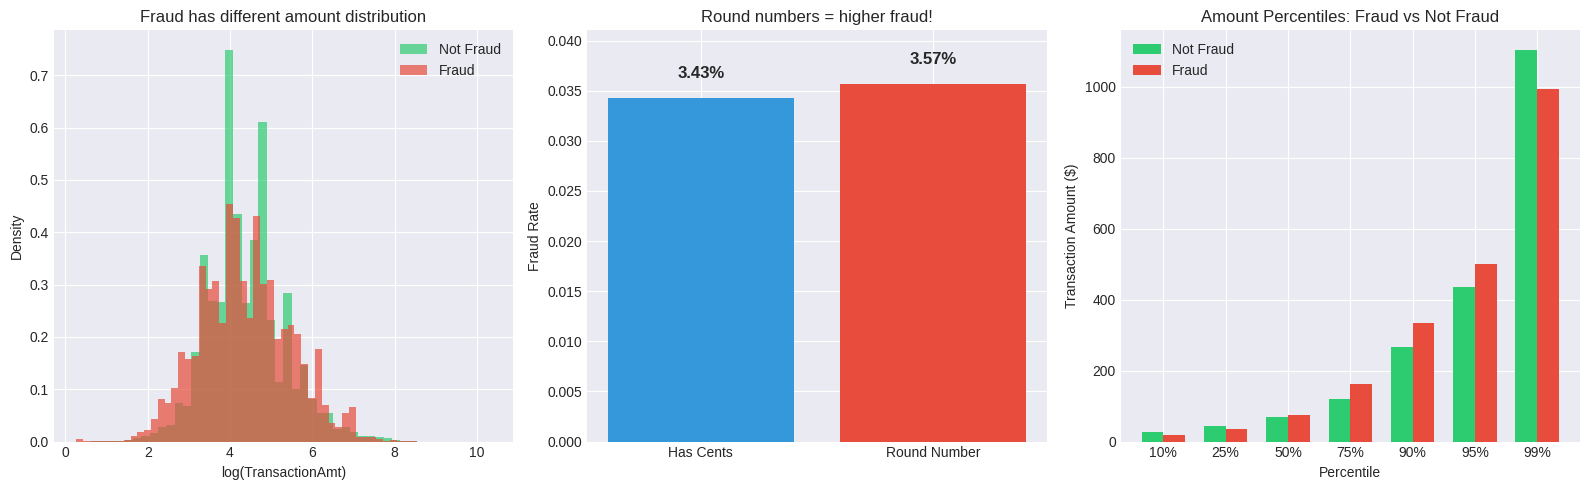

In [5]:
# Amount distribution for fraud vs non-fraud

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Log scale distribution
fraud_amt = train_df[train_df['isFraud']==1]['TransactionAmt']
nonfraud_amt = train_df[train_df['isFraud']==0]['TransactionAmt']

axes[0].hist(np.log1p(nonfraud_amt), bins=50, alpha=0.7, label='Not Fraud', color='#2ecc71', density=True)
axes[0].hist(np.log1p(fraud_amt), bins=50, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
axes[0].set_xlabel('log(TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].set_title('Fraud has different amount distribution')
axes[0].legend()

# Round number analysis
train_df['is_round'] = (train_df['TransactionAmt'] % 1 == 0).astype(int)
round_fraud = train_df.groupby('is_round')['isFraud'].mean()
colors = ['#3498db', '#e74c3c']
bars = axes[1].bar(['Has Cents', 'Round Number'], round_fraud.values, color=colors)
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Round numbers = higher fraud!')
axes[1].set_ylim(0, max(round_fraud.values) * 1.15)  # Add 15% padding at top
for i, v in enumerate(round_fraud.values):
    axes[1].text(i, v + 0.002, f'{v:.2%}', ha='center', fontweight='bold', fontsize=12)

# Amount percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
fraud_pct = [fraud_amt.quantile(p/100) for p in percentiles]
nonfraud_pct = [nonfraud_amt.quantile(p/100) for p in percentiles]

x = np.arange(len(percentiles))
width = 0.35
axes[2].bar(x - width/2, nonfraud_pct, width, label='Not Fraud', color='#2ecc71')
axes[2].bar(x + width/2, fraud_pct, width, label='Fraud', color='#e74c3c')
axes[2].set_xlabel('Percentile')
axes[2].set_ylabel('Transaction Amount ($)')
axes[2].set_title('Amount Percentiles: Fraud vs Not Fraud')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'{p}%' for p in percentiles])
axes[2].legend()

plt.tight_layout()
plt.show()

## Data Preparation

In [6]:
# Prepare features and target
X = train_df[feature_cols].fillna(-999)
y = train_df['isFraud']

X_test = test_df[feature_cols].fillna(-999)
test_ids = test_df['TransactionID']

print(f"Training data shape: {X.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True)}")

Training data shape: (590540, 461)
Test data shape: (506691, 461)

Class distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Class balance: isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


## Baseline Model Training

Let's start with a simple baseline model using default XGBoost parameters with GPU acceleration.

In [7]:
# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Training fraud rate: {y_train.mean():.2%}")
print(f"Validation fraud rate: {y_val.mean():.2%}")

Training set: (472432, 461)
Validation set: (118108, 461)
Training fraud rate: 3.50%
Validation fraud rate: 3.50%


In [8]:
%load_ext memory_profiler

In [9]:
%%memit

# Baseline XGBoost parameters with GPU
baseline_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'device': 'cuda',
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbosity': 1,
}

print("Training baseline model...")
start = time.perf_counter()

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)

baseline_model = xgb.train(
    baseline_params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=50
)

train_time = time.perf_counter() - start
print(f"\n⏱️ Training time: {train_time:.2f}s")

# Evaluate baseline model
y_pred_train = baseline_model.predict(dtrain)
y_pred_val = baseline_model.predict(dval)

train_auc = roc_auc_score(y_train, y_pred_train)
val_auc = roc_auc_score(y_val, y_pred_val)

print("\n" + "="*60)
print("📊 BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"Training AUC:   {train_auc:.5f}")
print(f"Validation AUC: {val_auc:.5f}")
print(f"Best iteration: {baseline_model.best_iteration}")
print("="*60)

Training baseline model...
[0]	train-auc:0.78125	val-auc:0.78211
[50]	train-auc:0.92496	val-auc:0.91840
[100]	train-auc:0.94166	val-auc:0.93112
[150]	train-auc:0.95116	val-auc:0.93782
[200]	train-auc:0.95964	val-auc:0.94415
[250]	train-auc:0.96546	val-auc:0.94834
[300]	train-auc:0.97050	val-auc:0.95184
[350]	train-auc:0.97493	val-auc:0.95529
[400]	train-auc:0.97860	val-auc:0.95792
[450]	train-auc:0.98152	val-auc:0.95998
[499]	train-auc:0.98385	val-auc:0.96142

⏱️ Training time: 5.54s

📊 BASELINE MODEL PERFORMANCE
Training AUC:   0.98385
Validation AUC: 0.96142
Best iteration: 499
peak memory: 9364.73 MiB, increment: 3856.39 MiB


In [10]:
# Evaluate baseline model
y_pred_train = baseline_model.predict(dtrain)
y_pred_val = baseline_model.predict(dval)

train_auc = roc_auc_score(y_train, y_pred_train)
val_auc = roc_auc_score(y_val, y_pred_val)

print("\n" + "="*60)
print("📊 BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"Training AUC:   {train_auc:.5f}")
print(f"Validation AUC: {val_auc:.5f}")
print(f"Best iteration: {baseline_model.best_iteration}")
print("="*60)


📊 BASELINE MODEL PERFORMANCE
Training AUC:   0.98385
Validation AUC: 0.96142
Best iteration: 499


## Feature Importance Analysis

In [11]:
# Get feature importance from baseline model
importance_dict = baseline_model.get_score(importance_type='gain')

# Convert to DataFrame for easier manipulation
importance_df = pd.DataFrame([
    {'feature': k, 'importance': v} 
    for k, v in importance_dict.items()
]).sort_values('importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
print("="*60)
for idx, row in importance_df.head(20).iterrows():
    print(f"{row['feature']:40s} {row['importance']:>15,.0f}")
print("="*60)


Top 20 Most Important Features:
V258                                               2,056
V225                                               1,100
V201                                                 689
V149                                                 427
V91                                                  355
V294                                                 216
C7                                                   205
V147                                                 195
id_17                                                140
V295                                                 119
V90                                                  113
V70                                                  110
C14                                                  106
C8                                                    95
R_email_gmail                                         82
R_email_common                                        81
V219                                                  7

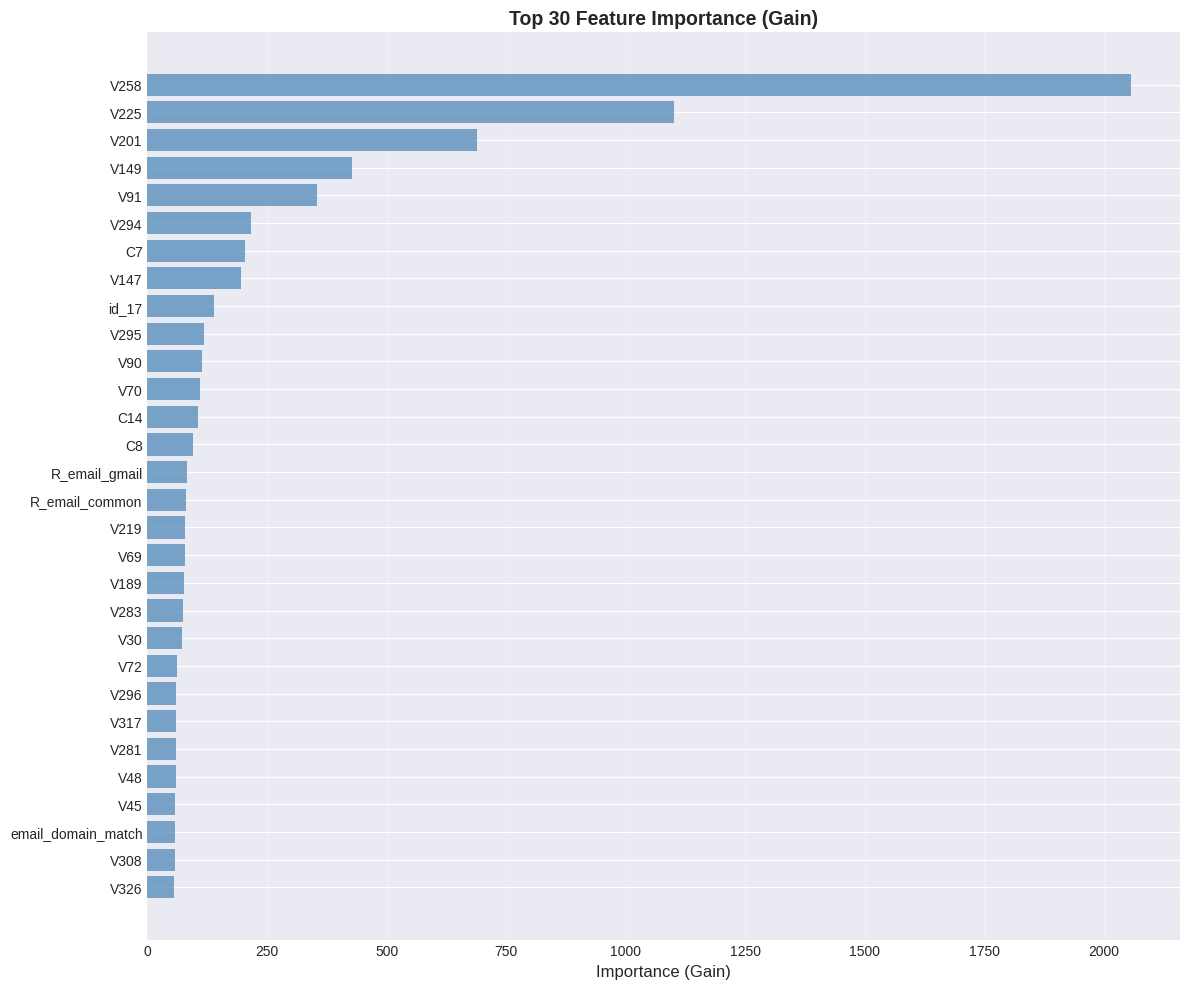

In [12]:
# # Visualize top 30 features
# fig, ax = plt.subplots(figsize=(12, 10))

# top_features = importance_df.head(30)
# ax.barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.7)
# ax.set_yticks(range(len(top_features)))
# ax.set_yticklabels(top_features['feature'])
# ax.invert_yaxis()
# ax.set_xlabel('Importance (Gain)', fontsize=12)
# ax.set_title('Top 30 Feature Importance (Gain)', fontsize=14, fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x')

# plt.tight_layout()
# plt.show()

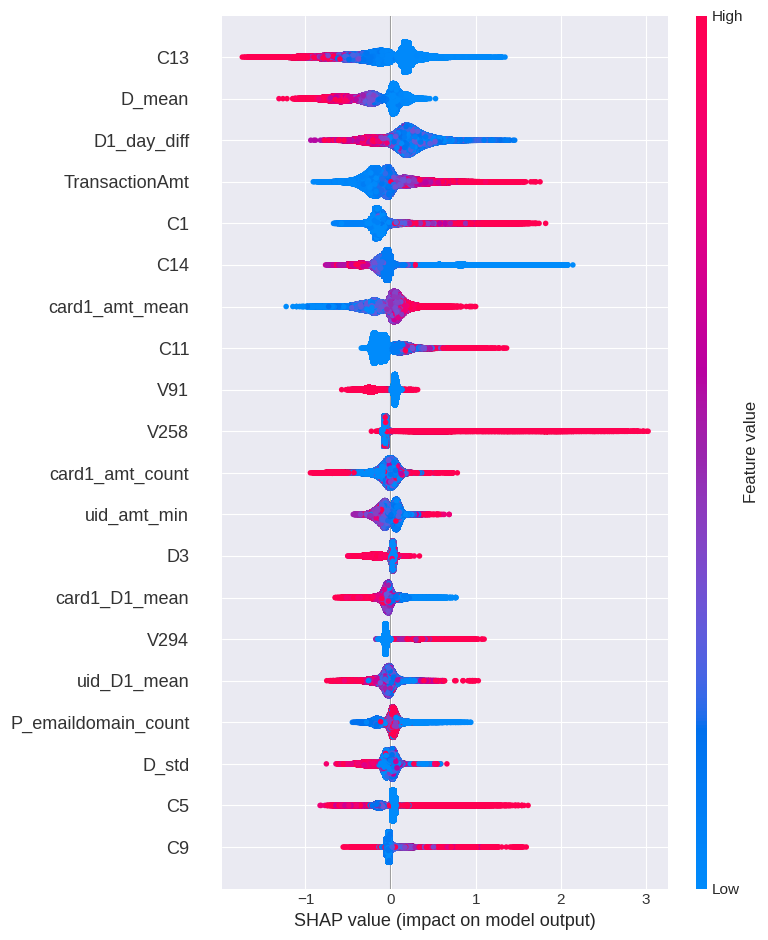

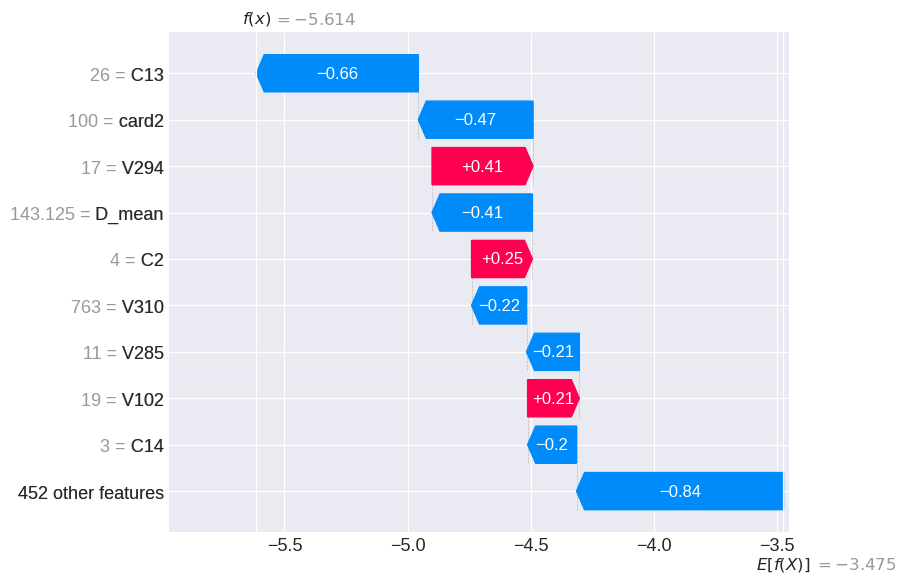

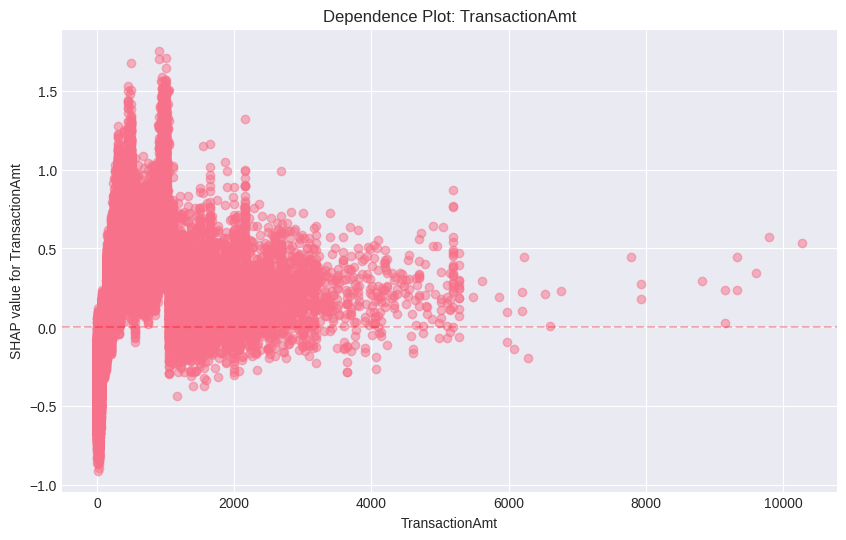

In [13]:
# Create SHAP explainer
explainer = shap.TreeExplainer(baseline_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Visualizations
# 1. Summary plot (feature importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 2. Detailed summary plot
shap.summary_plot(shap_values, X_test)

# 3. Force plot for a single prediction
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

# 4. Waterfall plot for a single prediction
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0], 
    base_values=explainer.expected_value, 
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))

# 5. Manual dependence plot (to avoid the error)
feature_idx = 0  # Change to desired feature
feature_name = X_test.columns[feature_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, feature_idx], shap_values[:, feature_idx], alpha=0.5)
plt.xlabel(feature_name)
plt.ylabel(f'SHAP value for {feature_name}')
plt.title(f'Dependence Plot: {feature_name}')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.show()

## 6.9 Generate Predictions

In [ ]:
# Generate predictions on test set
print("Generating predictions on test set...")
dtest = xgb.DMatrix(X_test)
test_predictions = baseline_model.predict(dtest)

print(f"\nPrediction statistics:")
print(f"  Min:    {test_predictions.min():.6f}")
print(f"  Max:    {test_predictions.max():.6f}")
print(f"  Mean:   {test_predictions.mean():.6f}")
print(f"  Median: {np.median(test_predictions):.6f}")
print(f"\nPredicted fraud rate: {(test_predictions > 0.5).mean():.2%}")